<a href="https://colab.research.google.com/github/nehalnova/sentiment-analysis-/blob/main/01_IMDB_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd



DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/IMDB Dataset.csv"

df = pd.read_csv(DATA_PATH)

Mounted at /content/drive


In [2]:
df.head() #displays the first 5 rows of df . quickly inspect the dataset

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.shape

(50000, 2)

In [4]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [5]:
df.info() #tells us about missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


From `df.info()`, we can infer:
*   There are 50,000 entries, no missing values in either column.
*   The memory usage is relatively low, which is good for text data of this size.



In [6]:
df.isnull().sum()#first part checks every cell in df
#When you apply .sum() to this boolean DataFrame, it counts the True values (which represent missing values) for each column. Since True is treated as 1 and False as 0, sum() effectively gives you the total number of missing entries per column.

,0
review,0
sentiment,0


In [7]:
df["sentiment"].value_counts()#selects a specific column and then calculates the occurances types

,count
sentiment,
positive,25000
negative,25000


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

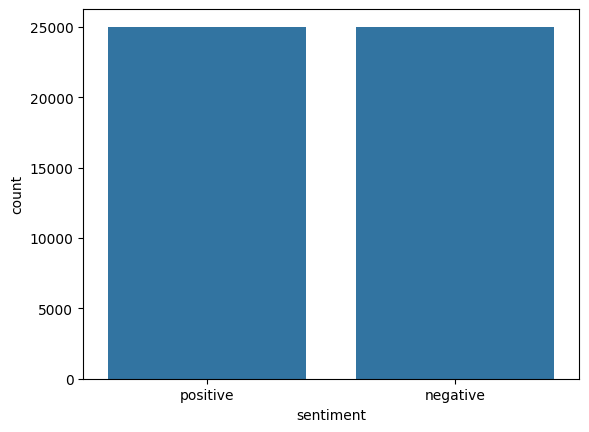

In [9]:
sns.countplot(x="sentiment", data=df)

plt.show()#same thing all together some code blocks

### Sentiment Distribution : dataset is distributed equally between positive and negative reviews

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


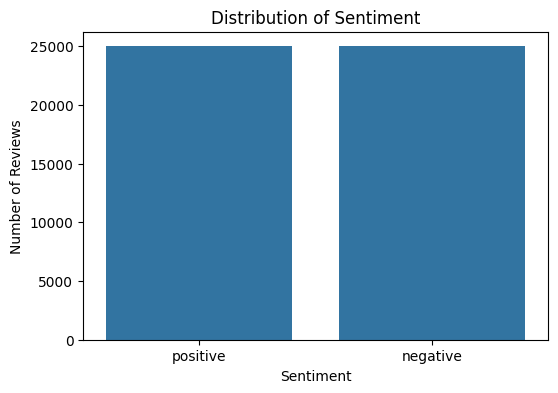

In [10]:
sentiment_counts = df['sentiment'].value_counts()#how many +ve and -ve values of sentiments are there in the dataset
print(sentiment_counts)#prints that values

import matplotlib.pyplot as plt#use these libraries to create and display a bar plot
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title('Distribution of Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()#look if the data is actually balanced or not can infer from the graphs

In [11]:
import re
import nltk

from nltk.corpus import stopwords

In [12]:
nltk.download('stopwords')
STOP_WORDS = set(stopwords.words("english"))

print(list(STOP_WORDS)[:20])
def clean_text(text):

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Keep only letters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Split into words
    words = text.split()

    # Remove stopwords
    words = [
        word
        for word in words
        if word not in STOP_WORDS
    ]

    return " ".join(words)


['himself', "should've", 'while', "i've", 'out', 'what', 'll', 'couldn', "she'd", 're', 'their', 'any', 'shan', 'very', 'being', 'had', "it'd", 'mustn', 'over', 'as']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [13]:
sample = "This movie was AMAZING!!! <br /><br /> I loved it 100%."

print(clean_text(sample))

movie amazing loved


In [14]:
df["clean_review"] = df["review"].apply(clean_text)

In [15]:
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching oz episode ho...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


In [16]:
print("ORIGINAL:\n")
print(df["review"].iloc[0])

print("\n" + "="*100 + "\n")

print("CLEANED:\n")
print(df["clean_review"].iloc[0])

ORIGINAL:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due

In [17]:
print(df.columns)

Index(['review', 'sentiment', 'clean_review'], dtype='object')


In [18]:
print(df["review"].iloc[0][:300])
df["review"].head()
df["clean_review"].head()

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru


,clean_review
0,one reviewers mentioned watching oz episode ho...
1,wonderful little production filming technique ...
2,thought wonderful way spend time hot summer we...
3,basically family little boy jake thinks zombie...
4,petter mattei love time money visually stunnin...


In [19]:

df["clean_review"] = df["review"].apply(clean_text)
print("ORIGINAL:")
print(df["review"].iloc[0][:300])

print("\n")

print("CLEANED:")
print(df["clean_review"].iloc[0][:300])

ORIGINAL:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru


CLEANED:
one reviewers mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use word called oz nickname given oswald maximum secur


Importing tfidf

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer #
tfidf = TfidfVectorizer(
    max_features=5000
)

In [21]:
X = tfidf.fit_transform(df["clean_review"]) #convert text to numbers

In [22]:
print(X.shape)

(50000, 5000)


In [23]:
tfidf.get_feature_names_out()[:20]

array(['aaron', 'abandoned', 'abc', 'abilities', 'ability', 'able',
       'absence', 'absent', 'absolute', 'absolutely', 'absurd', 'abuse',
       'abused', 'abusive', 'abysmal', 'academy', 'accent', 'accents',
       'accept', 'acceptable'], dtype=object)

In [24]:
print(X[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 102 stored elements and shape (1, 5000)>
  Coords	Values
  (0, 3103)	0.021827238444865726
  (0, 3691)	0.0792476797089306
  (0, 2794)	0.06832641147615395
  (0, 4840)	0.08045539400213889
  (0, 3147)	0.5556921710706617
  (0, 1479)	0.11933444573506098
  (0, 2135)	0.08669934179048938
  (0, 3707)	0.0894879323486094
  (0, 1525)	0.06024047775894111
  (0, 2014)	0.05998866624770228
  (0, 1718)	0.06634008473698393
  (0, 4466)	0.04040122572776445
  (0, 4256)	0.17339868358097876
  (0, 3834)	0.039719696189894196
  (0, 4770)	0.2443587914664922
  (0, 3918)	0.048661752398537206
  (0, 4945)	0.12242597645164832
  (0, 1907)	0.039274021285790245
  (0, 4616)	0.07608629252580455
  (0, 3973)	0.12603003499459514
  (0, 2053)	0.08080483699943034
  (0, 3461)	0.08259604546759877
  (0, 1345)	0.07623087690976454
  (0, 3928)	0.05613456581554082
  (0, 2021)	0.09024243564749951
  :	:
  (0, 1925)	0.04384540943860101
  (0, 2564)	0.07967513492352239
  (0, 1940)

In [25]:
tfidf.get_feature_names_out()[:20]
print(X[0])#x contains rn 50000 reviews × 5000 TF-IDF features

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 102 stored elements and shape (1, 5000)>
  Coords	Values
  (0, 3103)	0.021827238444865726
  (0, 3691)	0.0792476797089306
  (0, 2794)	0.06832641147615395
  (0, 4840)	0.08045539400213889
  (0, 3147)	0.5556921710706617
  (0, 1479)	0.11933444573506098
  (0, 2135)	0.08669934179048938
  (0, 3707)	0.0894879323486094
  (0, 1525)	0.06024047775894111
  (0, 2014)	0.05998866624770228
  (0, 1718)	0.06634008473698393
  (0, 4466)	0.04040122572776445
  (0, 4256)	0.17339868358097876
  (0, 3834)	0.039719696189894196
  (0, 4770)	0.2443587914664922
  (0, 3918)	0.048661752398537206
  (0, 4945)	0.12242597645164832
  (0, 1907)	0.039274021285790245
  (0, 4616)	0.07608629252580455
  (0, 3973)	0.12603003499459514
  (0, 2053)	0.08080483699943034
  (0, 3461)	0.08259604546759877
  (0, 1345)	0.07623087690976454
  (0, 3928)	0.05613456581554082
  (0, 2021)	0.09024243564749951
  :	:
  (0, 1925)	0.04384540943860101
  (0, 2564)	0.07967513492352239
  (0, 1940)

In [26]:
y = df["sentiment"]

print(y.head())

0    positive
1    positive
2    positive
3    negative
4    positive
Name: sentiment, dtype: object


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
print(X_train.shape)
print(X_test.shape)

(40000, 5000)
(10000, 5000)


In [29]:
from sklearn.linear_model import LogisticRegression #importing losgistic regression

In [30]:
model = LogisticRegression(max_iter=1000)#opti algo needs steps to convert (learned this in OTAIML)

In [31]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [32]:
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4961
    positive       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



NLP pipeline built -> Raw Review
      ->
Cleaning
      ->
TF-IDF
      ->
Train/Test Split
      ->
Logistic Regression
      ->
89% Accuracy

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm) #model is making mistakes here

[[4353  608]
 [ 469 4570]]


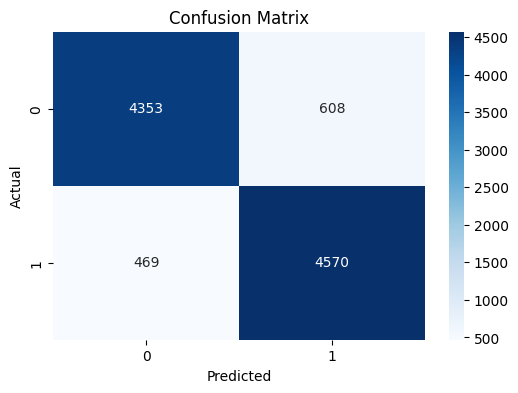

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

learning why the nlp moved from  TF-IDF → Word2Vec → LSTM → BERT

In [36]:
df["review"]

,review
0,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is..."
...,...
49995,I thought this movie did a down right good job...
49996,"Bad plot, bad dialogue, bad acting, idiotic di..."
49997,I am a Catholic taught in parochial elementary...
49998,I'm going to have to disagree with the previou...


BERT learns from natural language

In [37]:
import torch

print(torch.cuda.is_available())

True


In [38]:
!pip install transformers datasets accelerate -q

In [39]:
df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

df[["sentiment","label"]].head()

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [40]:
df_small = df.sample(
    n=10000,
    random_state=42
)

df_small.shape

(10000, 4)

In [41]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_small["review"],
    df_small["label"],
    test_size=0.2,
    random_state=42
)

In [42]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [43]:
sample = "This movie is not good."

tokens = tokenizer(sample)

print(tokens)

{'input_ids': [101, 2023, 3185, 2003, 2025, 2204, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}


In [44]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=256
)

In [45]:
import torch

class IMDbDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels.iloc[idx])

        return item

    def __len__(self):
        return len(self.labels)

In [46]:
train_dataset = IMDbDataset(
    train_encodings,
    train_labels
)

test_dataset = IMDbDataset(
    test_encodings,
    test_labels
)

In [47]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [48]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [49]:
train_dataset[0]

{'input_ids': tensor([  101,  1045,  2387,  2009,  3892,  1998,  3062,  6680,  1999,  1996,
          3185,  1012,  1026,  7987,  1013,  1028,  1026,  7987,  1013,  1028,
          2008,  2003,  2242,  2008,  1045,  2031,  2025,  2589,  2144,  1011,
          1045,  2031,  2196,  5357,  6680,  2012,  1996,  5691,  1012,  1026,
          7987,  1013,  1028,  1026,  7987,  1013,  1028,  1045,  2293,  1996,
          2434,  1998,  2031,  2464,  2009,  2195,  2335,  1998, 16755,  2009,
          2000,  3071,  1012,  2023,  2089,  2031,  2042,  1996,  3291,  2021,
          1045,  2079,  2025,  2228,  2061,  1010,  2138,  2045,  2020,  1037,
          3232,  1997,  4408,  7516,  2008,  3662,  2065,  2589,  2157,  2027,
          2071,  2031,  2081,  2023,  3185,  2147,  1012,  1026,  7987,  1013,
          1028,  1026,  7987,  1013,  1028,  6655,  2618,  2001,  2104,  2109,
          1998,  4776,  2001,  2058,  2109,  1998, 28616, 10526,  1012,  1026,
          7987,  1013,  1028,  1026,  7

In [50]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.to(device)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [51]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.01,
    logging_dir="./logs"
)#learning so only 2 epochs

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [52]:
import numpy as np
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy
    }

In [53]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [54]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.344868,0.262177,0.901000
2,0.157514,0.316274,0.898500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1000, training_loss=0.25119129943847657, metrics={'train_runtime': 422.107, 'train_samples_per_second': 37.905, 'train_steps_per_second': 2.369, 'total_flos': 1059739189248000.0, 'train_loss': 0.25119129943847657, 'epoch': 2.0})

In [55]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy
0.157514,0.316274,2,0.898500


{'eval_loss': 0.3162737488746643, 'eval_accuracy': 0.8985}